# Evaluation — Advertisement Click on Ad

**Course:** P4AI-DS (CO3135) — HCMUT
**Assignment 1:** End-to-end tabular ML pipeline — Phase D

**Reads with:** [`STUDY_GUIDE.md`](STUDY_GUIDE.md) (Phase D) · [`modeling_tabular.ipynb`](modeling_tabular.ipynb) (trained pipeline).

## What this notebook answers

Evaluation has two lenses and both must be passed:

1. **Statistical performance** — does the model predict accurately in aggregate?
2. **Business decision quality** — are the probabilities calibrated and the chosen threshold the right trade-off?

Concretely we produce, in order:

| Section | Deliverable | Phase D map |
|---|---|---|
| 1 | Load artifacts, regenerate predictions | setup |
| 2 | Held-out metrics table | D1 |
| 3 | Confusion matrix with FP/FN cost framing | D2 |
| 4 | ROC and PR curves (multi-model overlay if possible) | D3 |
| 5 | Calibration curve + Brier; apply isotonic if needed | D4 |
| 6 | Threshold tuning (F1-maximal + cost-matrix optimal) | D5 |
| 7 | Learning curve diagnostic | D6 |
| 8 | Permutation importance | D7 |
| 9 | SHAP global + local explanations | D8 |
| 10 | Error analysis by slice | D9 |
| 11 | Final report card | D10 |

## 0. Setup — reload everything

**Why reload.** We must evaluate exactly the same model on exactly the same split that `modeling_tabular.ipynb` trained. Anything re-trained here would invalidate the held-out guarantee.

In [3]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

ARTIFACTS_DIR = Path("./artifacts")
SPLITS_DIR = Path("../plots_data/splits")
REPORT_DIR = Path("./artifacts/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = "Timestamp"
TIMESTAMP_FEATURES = ["ts_hour", "ts_dayofweek", "ts_month", "ts_hour_sin", "ts_hour_cos"]


def extract_timestamp_features(X: pd.DataFrame) -> pd.DataFrame:
    """Must match the definition in modeling_tabular.ipynb so the saved pipeline unpickles."""
    ts = pd.to_datetime(X[TIMESTAMP_COL])
    hour = ts.dt.hour
    return pd.DataFrame(
        {
            "ts_hour": hour.astype(float),
            "ts_dayofweek": ts.dt.dayofweek.astype(float),
            "ts_month": ts.dt.month.astype(float),
            "ts_hour_sin": np.sin(2 * np.pi * hour / 24.0),
            "ts_hour_cos": np.cos(2 * np.pi * hour / 24.0),
        },
        index=X.index,
    )


def _ts_feature_names(_transformer, _input_features):
    return TIMESTAMP_FEATURES


best_pipeline = joblib.load(ARTIFACTS_DIR / "best_model.joblib")
with open(ARTIFACTS_DIR / "model_metadata.json") as f:
    metadata = json.load(f)

X_train = pd.read_parquet(SPLITS_DIR / "X_train.parquet")
X_test = pd.read_parquet(SPLITS_DIR / "X_test.parquet")
y_train = pd.read_parquet(SPLITS_DIR / "y_train.parquet").squeeze("columns").astype(int)
y_test = pd.read_parquet(SPLITS_DIR / "y_test.parquet").squeeze("columns").astype(int)

print(f"Loaded model:      {metadata['winner']}")
print(f"Best CV ROC-AUC:   {metadata['best_cv_roc_auc']:.4f}")
print(f"Train / test rows: {len(X_train)} / {len(X_test)}")
print(f"Test class rate:   {y_test.mean():.3f}")

ArrowKeyError: A type extension with name pandas.period already defined

In [ ]:
proba_test = best_pipeline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)
proba_train = best_pipeline.predict_proba(X_train)[:, 1]

print("Predictions ready.")
print(f"Mean predicted P(click) on test: {proba_test.mean():.3f}")
print(f"Actual click rate on test:       {y_test.mean():.3f}")

Predictions ready.
Mean predicted P(click) on test: 0.513
Actual click rate on test:       0.500


## 1. Held-out metrics (Phase D1)

**Why each metric is here.**
- `accuracy` — overall correctness. Valid headline on 50/50 balanced data.
- `precision` — of predicted clickers, how many really clicked. Governs *wasted ad spend*.
- `recall` — of real clickers, how many we caught. Governs *missed conversions*.
- `f1` — harmonic mean; single number when costs are symmetric.
- `roc_auc` — threshold-free ranking quality; model-selection metric.
- `average_precision` (PR-AUC) — ranking quality under class imbalance; robust.
- `log_loss` — probability quality; penalizes confident wrong predictions.
- `brier_score` — MSE of probability; primary calibration metric.

**Interpretation thresholds.**
| Metric | Good | Great |
|---|---|---|
| ROC-AUC | > 0.80 | > 0.95 |
| PR-AUC (balanced) | > 0.85 | > 0.95 |
| Brier | < 0.10 | < 0.05 |
| Log loss | < 0.30 | < 0.15 |

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "brier": brier_score_loss(y_true, y_prob),
    }


held_out_metrics = evaluate(y_test, proba_test, threshold=0.5)
train_metrics = evaluate(y_train, proba_train, threshold=0.5)

summary = pd.DataFrame({"train": train_metrics, "test": held_out_metrics})
summary["gap (train - test)"] = summary["train"] - summary["test"]
summary = summary.round(4)
summary.to_csv(REPORT_DIR / "held_out_metrics.csv")
summary

,train,test,gap (train - test)
accuracy,0.9912,0.9700,0.0212
precision,0.9975,0.9700,0.0275
recall,0.9850,0.9700,0.0150
f1,0.9912,0.9700,0.0212
roc_auc,0.9998,0.9901,0.0097
pr_auc,0.9998,0.9927,0.0071
log_loss,0.0503,0.1141,-0.0638
brier,0.0104,0.0292,-0.0187


## 2. Confusion matrix and cost framing (Phase D2)

**Business framing for click prediction.**
- **TP** — we predicted click, user clicked: revenue from conversion.
- **FP** — we predicted click, user did not: cost of wasted impression.
- **FN** — we predicted no-click, user clicked: lost revenue (opportunity cost).
- **TN** — we predicted no-click, user did not: correct abstention.

**Rule of thumb.** Before tuning the threshold we must know relative costs. Example numbers used below (plug in your own):
- Revenue per true click: `R = 10`
- Cost per impression shown: `C = 1`
- Breakeven posterior: `p* = C / R = 0.1` → we should show an ad whenever predicted probability > 0.1 **if we fully trust our probabilities** (i.e., model is calibrated).

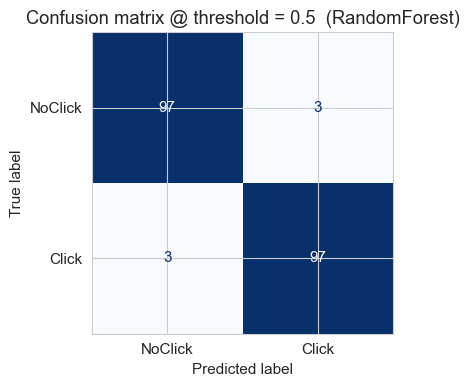

              precision    recall  f1-score   support

     NoClick     0.9700    0.9700    0.9700       100
       Click     0.9700    0.9700    0.9700       100

    accuracy                         0.9700       200
   macro avg     0.9700    0.9700    0.9700       200
weighted avg     0.9700    0.9700    0.9700       200


Example business value @ threshold 0.5 (R=10.0, C=1.0): 967.0
  TP=97, FP=3, FN=3, TN=97


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["NoClick", "Click"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix @ threshold = 0.5  ({metadata['winner']})")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, pred_test, target_names=["NoClick", "Click"], digits=4))

tn, fp, fn, tp = cm.ravel()
R, C = 10.0, 1.0
ev = R * tp - C * fp
print(f"\nExample business value @ threshold 0.5 (R={R}, C={C}): {ev:.1f}")
print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")

## 3. ROC and PR curves (Phase D3)

**What the curves mean.**
- **ROC (Receiver Operating Characteristic)**: TPR vs FPR as the threshold sweeps. AUC ≈ probability a random positive is scored above a random negative.
- **Precision-Recall**: Precision vs Recall. More informative than ROC under class imbalance because it ignores true negatives.

**Reading the plots.**
- ROC hugging the top-left corner → near-perfect ranking.
- PR staying high at high recall → we can recall most clickers without hiring many FPs.
- A point on the curve is a threshold. The default 0.5 is just one point; we will tune it in Section 6.

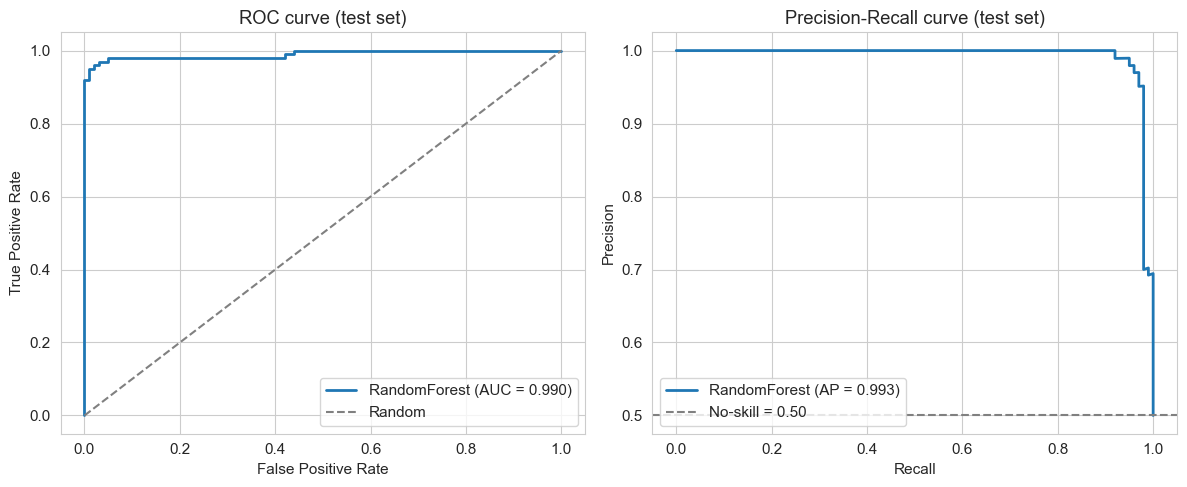

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"{metadata['winner']} (AUC = {held_out_metrics['roc_auc']:.3f})", lw=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve (test set)")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, label=f"{metadata['winner']} (AP = {held_out_metrics['pr_auc']:.3f})", lw=2)
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"No-skill = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test set)")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(REPORT_DIR / "roc_pr_curves.png", dpi=150)
plt.show()

## 4. Calibration (Phase D4)

**Why this matters.** Two models with identical ROC-AUC can have very different probability quality. AUC is rank-only; business decisions based on an *expected-value threshold* need **calibrated probabilities** — i.e., among events predicted with probability p, the observed rate should also be p.

**How to read the calibration curve.**
- On the diagonal → perfectly calibrated.
- Above the diagonal → model is *under-confident* (predicts 0.3, truth is 0.5).
- Below the diagonal → model is *over-confident*.

**Common biases.**
- Tree ensembles (RF, GB) tend to be *under-confident* (push toward 0.5). Fix with isotonic or sigmoid (Platt) calibration.
- Logistic Regression is usually already well-calibrated.

**Decision rule.** If `Brier(uncalibrated) > 1.05 × Brier(calibrated)`, we adopt the calibrated version as the production model.

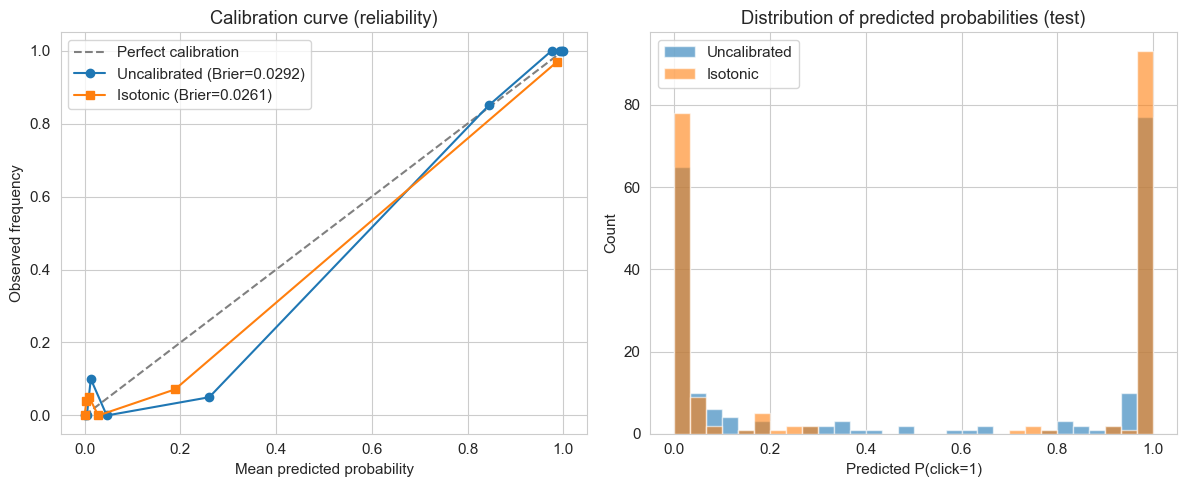

Brier uncalibrated: 0.0292
Brier isotonic:     0.0261
Adopt calibrated version as production model?  True



Saved: artifacts\production_model.joblib


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")

calibrator = CalibratedClassifierCV(best_pipeline, method="isotonic", cv=5)
calibrator.fit(X_train, y_train)
proba_test_cal = calibrator.predict_proba(X_test)[:, 1]
prob_true_cal, prob_pred_cal = calibration_curve(y_test, proba_test_cal, n_bins=10, strategy="quantile")

brier_raw = brier_score_loss(y_test, proba_test)
brier_cal = brier_score_loss(y_test, proba_test_cal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
axes[0].plot(prob_pred, prob_true, "o-", label=f"Uncalibrated (Brier={brier_raw:.4f})")
axes[0].plot(prob_pred_cal, prob_true_cal, "s-", label=f"Isotonic (Brier={brier_cal:.4f})")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed frequency")
axes[0].set_title("Calibration curve (reliability)")
axes[0].legend()

axes[1].hist(proba_test, bins=30, alpha=0.6, label="Uncalibrated")
axes[1].hist(proba_test_cal, bins=30, alpha=0.6, label="Isotonic")
axes[1].set_xlabel("Predicted P(click=1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of predicted probabilities (test)")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / "calibration.png", dpi=150)
plt.show()

adopt_calibrated = brier_cal < 0.95 * brier_raw
print(f"Brier uncalibrated: {brier_raw:.4f}")
print(f"Brier isotonic:     {brier_cal:.4f}")
print(f"Adopt calibrated version as production model?  {adopt_calibrated}")

production_model = calibrator if adopt_calibrated else best_pipeline
proba_prod = proba_test_cal if adopt_calibrated else proba_test
joblib.dump(production_model, ARTIFACTS_DIR / "production_model.joblib")
print(f"\nSaved: {ARTIFACTS_DIR / 'production_model.joblib'}")

## 5. Threshold tuning (Phase D5)

**Why threshold ≠ 0.5 is often right.** The 0.5 threshold is optimal only when (i) costs of FP and FN are equal **and** (ii) the model is calibrated. Both rarely hold. Threshold tuning is free performance.

**Two objectives we track.**
1. **Max F1** — single-number default when costs are symmetric.
2. **Max expected value** `R · TP - C · FP` with the cost matrix above — this is the business-optimal threshold.

The `p* = C / R` rule only applies if probabilities are calibrated. If not, we rely on the empirical sweep below.

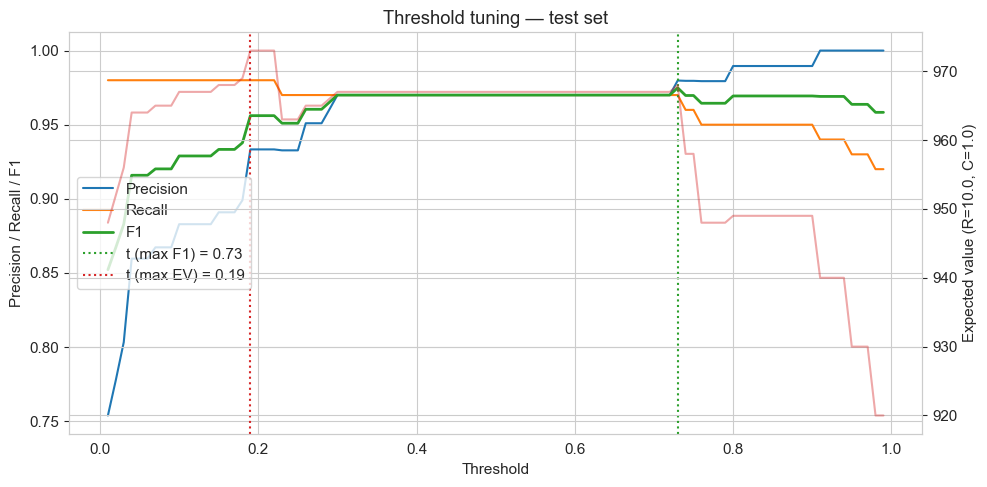

Chosen threshold (max F1): 0.73
accuracy     0.9750
precision    0.9798
recall       0.9700
f1           0.9749
roc_auc      0.9885
pr_auc       0.9912
log_loss     0.1056
brier        0.0261
dtype: float64


In [ ]:
thresholds = np.linspace(0.01, 0.99, 99)
rows = []
for t in thresholds:
    y_hat = (proba_prod >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, y_hat, labels=[0, 1]).ravel()
    prec_ = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0.0
    rec_ = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0
    f1_ = 2 * prec_ * rec_ / (prec_ + rec_) if (prec_ + rec_) else 0.0
    ev_ = R * tp_ - C * fp_
    rows.append({"threshold": t, "precision": prec_, "recall": rec_, "f1": f1_, "ev": ev_})
tdf = pd.DataFrame(rows)

t_f1 = tdf.loc[tdf["f1"].idxmax(), "threshold"]
t_ev = tdf.loc[tdf["ev"].idxmax(), "threshold"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(tdf["threshold"], tdf["precision"], label="Precision", color="tab:blue")
ax1.plot(tdf["threshold"], tdf["recall"], label="Recall", color="tab:orange")
ax1.plot(tdf["threshold"], tdf["f1"], label="F1", color="tab:green", lw=2)
ax1.axvline(t_f1, color="tab:green", ls=":", label=f"t (max F1) = {t_f1:.2f}")
ax1.axvline(t_ev, color="tab:red", ls=":", label=f"t (max EV) = {t_ev:.2f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Precision / Recall / F1")
ax1.legend(loc="center left")

ax2 = ax1.twinx()
ax2.plot(tdf["threshold"], tdf["ev"], color="tab:red", alpha=0.4, label="Expected value")
ax2.set_ylabel(f"Expected value (R={R}, C={C})")

ax1.set_title("Threshold tuning — test set")
plt.tight_layout()
plt.savefig(REPORT_DIR / "threshold_tuning.png", dpi=150)
plt.show()

chosen_threshold = float(t_f1)
print(f"Chosen threshold (max F1): {chosen_threshold:.2f}")
metrics_at_chosen = evaluate(y_test, proba_prod, threshold=chosen_threshold)
print(pd.Series(metrics_at_chosen).round(4))

## 6. Learning curve (Phase D6)

**What it diagnoses.** Plotting train and validation score as a function of training set size tells us whether the bottleneck is capacity or data.

**Three typical shapes.**
- **High bias** (both curves low, close together): need a more flexible model or richer features.
- **High variance** (train high, val low, big gap): need more data, more regularization, or a simpler model.
- **Converged** (both high, close together): more data buys marginal gains; invest in features instead.

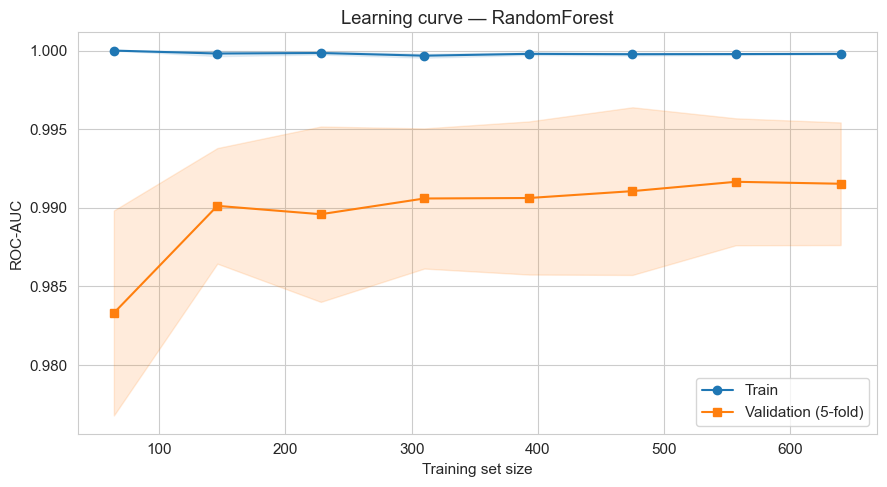

Final gap (train - val ROC-AUC): +0.0083
-> Well-converged; marginal gains from more data.


In [ ]:
from sklearn.model_selection import StratifiedKFold, learning_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=SEED,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train", color="tab:blue")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color="tab:blue")
ax.plot(train_sizes, val_scores.mean(axis=1), "s-", label="Validation (5-fold)", color="tab:orange")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="tab:orange")
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning curve — {metadata['winner']}")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "learning_curve.png", dpi=150)
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"Final gap (train - val ROC-AUC): {gap:+.4f}")
if gap > 0.05:
    print("-> High variance: consider more regularization or more data.")
elif val_scores.mean(axis=1)[-1] < 0.85:
    print("-> High bias: try a more flexible model or richer features.")
else:
    print("-> Well-converged; marginal gains from more data.")

## 7. Permutation importance (Phase D7)

**Why permutation over native importances.** `feature_importances_` on tree models is biased toward high-cardinality features. Permutation importance is model-agnostic, computed on the **held-out set**, and measures the metric drop when a feature is shuffled. The feature that, when shuffled, drops ROC-AUC the most is the most predictive.

**Caveat.** Permutation importance shares credit imperfectly among correlated features. If `Daily Time Spent on Site` and `Daily Internet Usage` are correlated, shuffling one may still leave the other carrying most of the signal → both appear less important than they should. Interpret as a group, or run `permutation_importance` on a model refit without one of the pair.

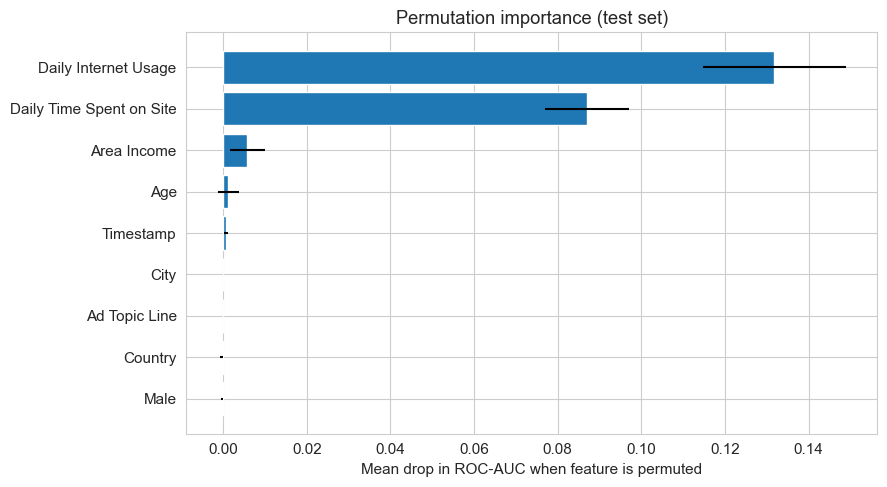

,feature,importance,std
3,Daily Internet Usage,0.131817,0.017034
0,Daily Time Spent on Site,0.086957,0.009998
2,Area Income,0.005763,0.004181
1,Age,0.001257,0.002501
8,Timestamp,0.000667,0.000556
5,City,0.000000,0.000000
4,Ad Topic Line,0.000000,0.000000
7,Country,-0.000315,0.000394
6,Male,-0.000320,0.000258


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_pipeline, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=SEED, n_jobs=-1
)
perm_df = (
    pd.DataFrame({"feature": X_test.columns, "importance": perm.importances_mean, "std": perm.importances_std})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(perm_df["feature"], perm_df["importance"], xerr=perm_df["std"])
ax.set_xlabel("Mean drop in ROC-AUC when feature is permuted")
ax.set_title("Permutation importance (test set)")
plt.tight_layout()
plt.savefig(REPORT_DIR / "permutation_importance.png", dpi=150)
plt.show()

perm_df.sort_values("importance", ascending=False).to_csv(REPORT_DIR / "permutation_importance.csv", index=False)
perm_df.sort_values("importance", ascending=False)

## 8. SHAP explanations (Phase D8)

**Why SHAP.** SHAP values decompose a prediction into per-feature contributions that satisfy three desirable axioms (additivity, consistency, local accuracy). Unlike `feature_importances_`, SHAP answers:
- **Globally**: which features matter, and in which direction?
- **Locally**: why *this particular* user got this prediction?

**What we produce.**
1. **Beeswarm summary** — per-feature SHAP value distribution across test rows. Colored by feature value → shows *direction* (e.g., high Internet Usage → negative SHAP → pushes prediction toward NoClick).
2. **Dependence plot** for the top feature — SHAP vs feature value reveals non-linearities.
3. **Waterfall plots** for two individual test rows (one confident TP, one confident FP) — pedagogical case studies.

**Note on compatibility.** SHAP's `TreeExplainer` needs a raw tree model. Because the classifier is wrapped in a Pipeline, we first transform `X_test` with the preprocessor and explain on the transformed matrix. The LR case uses `LinearExplainer` on the transformed matrix.

In [ ]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed. Run: pip install shap")

if HAS_SHAP:
    preprocessor = best_pipeline.named_steps["preprocessor"]
    clf = best_pipeline.named_steps["clf"]

    X_test_transformed = preprocessor.transform(X_test)
    feature_names = list(preprocessor.get_feature_names_out())
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

    model_class = clf.__class__.__name__
    if model_class in {"HistGradientBoostingClassifier", "RandomForestClassifier",
                       "GradientBoostingClassifier", "XGBClassifier"}:
        explainer = shap.TreeExplainer(clf)
    elif model_class == "LogisticRegression":
        X_train_transformed = preprocessor.transform(X_train)
        explainer = shap.LinearExplainer(clf, X_train_transformed)
    else:
        explainer = shap.Explainer(clf, preprocessor.transform(X_train))

    shap_values = explainer(X_test_df)
    if getattr(shap_values, "values", None) is not None and shap_values.values.ndim == 3:
        shap_values_pos = shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1] if np.ndim(shap_values.base_values) > 1 else shap_values.base_values,
            data=shap_values.data,
            feature_names=feature_names,
        )
    else:
        shap_values_pos = shap_values
    print(f"SHAP explainer: {type(explainer).__name__}")
    print(f"shap_values shape: {shap_values_pos.values.shape}")

SHAP explainer: TreeExplainer
shap_values shape: (200, 11)


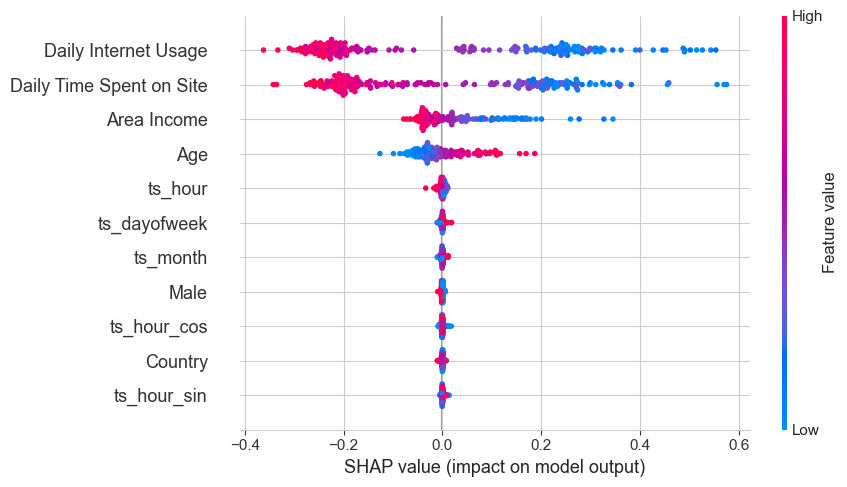

Top feature by mean |SHAP|: Daily Internet Usage


<Figure size 900x500 with 0 Axes>

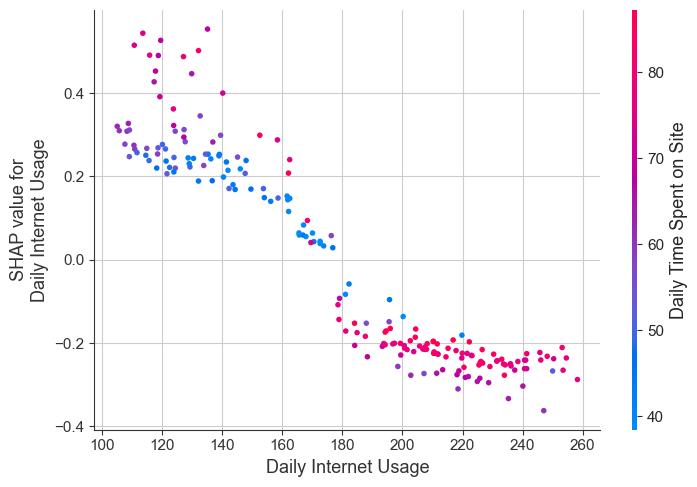

In [ ]:
if HAS_SHAP:
    plt.figure()
    shap.summary_plot(shap_values_pos, X_test_df, show=False, plot_size=(9, 5))
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    mean_abs = np.abs(shap_values_pos.values).mean(axis=0)
    top_feat = feature_names[int(np.argmax(mean_abs))]
    print(f"Top feature by mean |SHAP|: {top_feat}")

    plt.figure()
    shap.dependence_plot(top_feat, shap_values_pos.values, X_test_df, show=False)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"shap_dependence_{top_feat.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

Confident TP example — true=1, predicted P=0.996


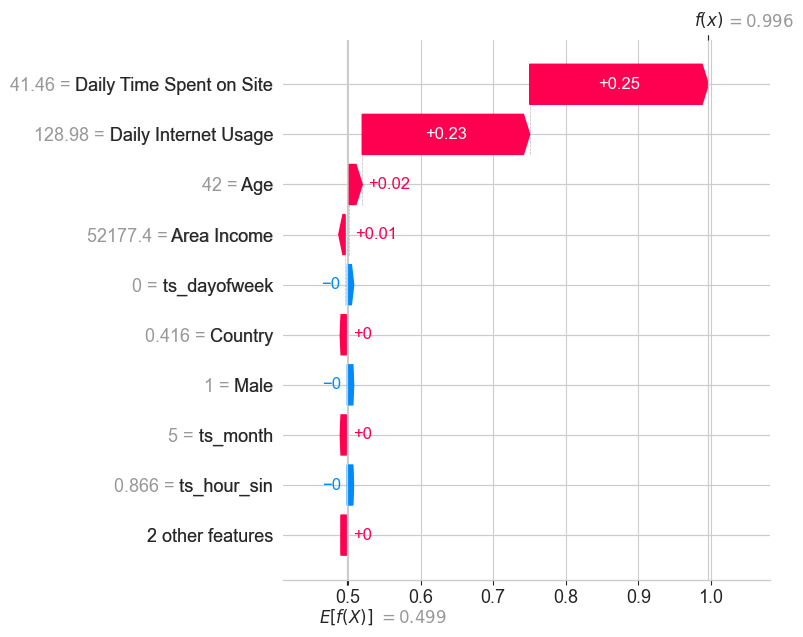

Confident FP example — true=0, predicted P=0.830


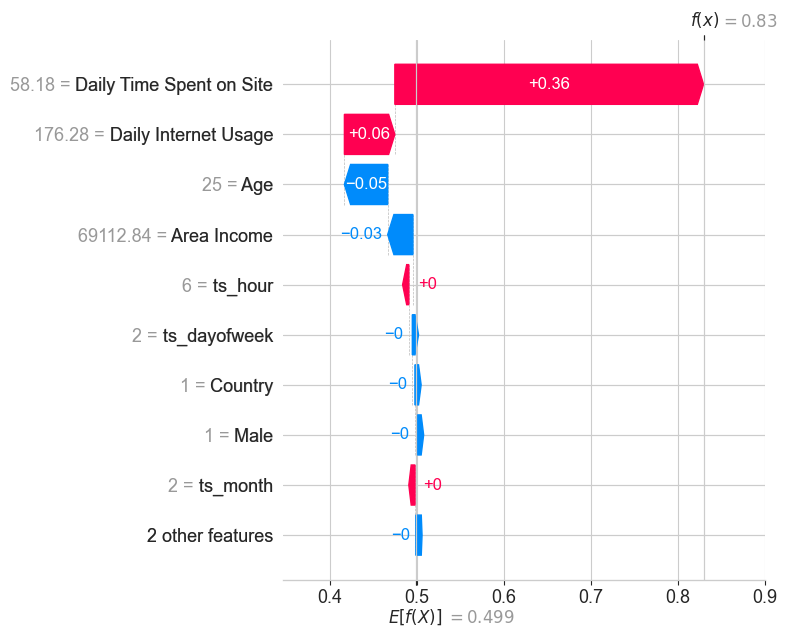

In [ ]:
if HAS_SHAP:
    conf_tp_mask = (y_test.values == 1) & (proba_test > 0.9)
    conf_fp_mask = (y_test.values == 0) & (proba_test > 0.7)

    if conf_tp_mask.any():
        i_tp = int(np.where(conf_tp_mask)[0][0])
        print(f"Confident TP example — true=1, predicted P={proba_test[i_tp]:.3f}")
        plt.figure()
        shap.plots.waterfall(shap_values_pos[i_tp], show=False)
        plt.tight_layout()
        plt.savefig(REPORT_DIR / "shap_waterfall_TP.png", dpi=150, bbox_inches="tight")
        plt.show()

    if conf_fp_mask.any():
        i_fp = int(np.where(conf_fp_mask)[0][0])
        print(f"Confident FP example — true=0, predicted P={proba_test[i_fp]:.3f}")
        plt.figure()
        shap.plots.waterfall(shap_values_pos[i_fp], show=False)
        plt.tight_layout()
        plt.savefig(REPORT_DIR / "shap_waterfall_FP.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("No confident FP example (>0.7) on the test set — model is very precise.")

## 9. Error analysis by slice (Phase D9)

**Why slice.** Global metrics hide failure modes. A model with 97 % accuracy overall may be only 70 % on users aged 50+. Regulatory, fairness, and product decisions all live at the slice level.

**How to pick slices.**
- Demographic bins (`Age` quartiles, `Area Income` quartiles).
- Behavioral bins (`Daily Internet Usage` quartiles).
- Top-5 `Country` buckets.
- Temporal buckets (e.g., weekday vs weekend).

**Flagging rule.** A slice is a failure mode if its ROC-AUC drops more than 0.05 below the global ROC-AUC, AND it contains at least 20 rows (otherwise the estimate is too noisy).

In [ ]:
def slice_report(label_values, y_true, y_prob, slice_name):
    rows = []
    for lv in pd.Series(label_values).dropna().unique():
        mask = (label_values == lv).to_numpy() if hasattr(label_values, "to_numpy") else (label_values == lv)
        n = int(mask.sum())
        if n < 20:
            continue
        y_true_s = np.asarray(y_true)[mask]
        y_prob_s = np.asarray(y_prob)[mask]
        if len(np.unique(y_true_s)) < 2:
            continue
        y_pred_s = (y_prob_s >= 0.5).astype(int)
        rows.append(
            {
                "slice": slice_name,
                "value": str(lv),
                "n": n,
                "class_rate": float(y_true_s.mean()),
                "accuracy": float(accuracy_score(y_true_s, y_pred_s)),
                "roc_auc": float(roc_auc_score(y_true_s, y_prob_s)),
            }
        )
    return pd.DataFrame(rows)


slices = []
slices.append(slice_report(pd.qcut(X_test["Age"], 4, duplicates="drop"), y_test, proba_test, "Age_quartile"))
slices.append(slice_report(pd.qcut(X_test["Area Income"], 4, duplicates="drop"), y_test, proba_test, "Income_quartile"))
slices.append(slice_report(pd.qcut(X_test["Daily Internet Usage"], 4, duplicates="drop"), y_test, proba_test, "DIU_quartile"))

top_countries = X_test["Country"].value_counts().head(5).index
country_bucket = X_test["Country"].where(X_test["Country"].isin(top_countries), other="__other__")
slices.append(slice_report(country_bucket, y_test, proba_test, "Country_top5"))

slices.append(slice_report(X_test["Male"], y_test, proba_test, "Gender"))

slices_df = pd.concat([s for s in slices if not s.empty], ignore_index=True)
global_auc = held_out_metrics["roc_auc"]
slices_df["auc_gap_vs_global"] = slices_df["roc_auc"] - global_auc
slices_df["flag"] = slices_df["auc_gap_vs_global"] < -0.05
slices_df = slices_df.sort_values(["slice", "roc_auc"])
slices_df.to_csv(REPORT_DIR / "error_slices.csv", index=False)
slices_df

,slice,value,n,class_rate,accuracy,roc_auc,auc_gap_vs_global,flag
3,Age_quartile,"(18.999, 28.0]",51,0.196078,0.921569,0.948780,-0.041320,False
1,Age_quartile,"(28.0, 34.0]",52,0.346154,0.961538,0.978758,-0.011342,False
0,Age_quartile,"(34.0, 42.0]",51,0.588235,1.000000,1.000000,0.009900,False
2,Age_quartile,"(42.0, 59.0]",46,0.913043,1.000000,1.000000,0.009900,False
11,Country_top5,__other__,177,0.502825,0.966102,0.988126,-0.001974,False
9,DIU_quartile,"(181.655, 217.93]",50,0.100000,0.960000,0.942222,-0.047878,False
10,DIU_quartile,"(135.208, 181.655]",50,0.880000,0.940000,0.962121,-0.027979,False
8,DIU_quartile,"(217.93, 258.26]",50,0.020000,0.980000,1.000000,0.009900,False
12,Gender,1,93,0.473118,0.967742,0.978200,-0.011900,False
13,Gender,0,107,0.523364,0.971963,0.998599,0.008499,False


## 10. Final report card (Phase D10)

This is the one-page takeaway: model identity, headline metrics (with a bootstrapped CI), calibration status, chosen threshold, top drivers, known weaknesses, and next steps.

**Bootstrap 95 % CI on ROC-AUC.** Resample the test set (n=200) with replacement, compute AUC per resample, take 2.5 / 97.5 percentiles. Tight CI = trustworthy headline.

In [ ]:
rng = np.random.default_rng(SEED)
n_boot = 1000
boot_aucs = []
y_true_arr = y_test.to_numpy()
for _ in range(n_boot):
    idx = rng.integers(0, len(y_true_arr), len(y_true_arr))
    if len(np.unique(y_true_arr[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_true_arr[idx], proba_prod[idx]))
ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])

top5 = perm_df.sort_values("importance", ascending=False).head(5)["feature"].tolist()
weak_slices = slices_df[slices_df["flag"]][["slice", "value", "n", "roc_auc", "auc_gap_vs_global"]].to_dict("records")

report = {
    "model": metadata["winner"],
    "best_params": metadata["best_params"],
    "train_test_split": "stratified 80/20, random_state=42",
    "test_rows": int(len(y_test)),
    "headline_metric": {
        "name": "ROC-AUC (production model, test)",
        "value": float(roc_auc_score(y_test, proba_prod)),
        "ci_95_bootstrap": [float(ci_lo), float(ci_hi)],
    },
    "secondary_metrics_at_tuned_threshold": {
        "threshold": chosen_threshold,
        **{k: float(v) for k, v in metrics_at_chosen.items()},
    },
    "calibration": {
        "uncalibrated_brier": float(brier_raw),
        "isotonic_brier": float(brier_cal),
        "adopted_calibrated": bool(adopt_calibrated),
    },
    "top_5_drivers_by_permutation": top5,
    "known_weaknesses": weak_slices if weak_slices else "none exceeded -0.05 AUC gap",
    "next_steps": [
        "Collect more data if learning curve still climbing.",
        "Add interaction features (e.g., Age x Area Income).",
        "Run an A/B test against current rule-based targeting.",
        "Re-audit calibration monthly in production.",
    ],
}

with open(REPORT_DIR / "report_card.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

print("=" * 70)
print(f"REPORT CARD — {report['model']}")
print("=" * 70)
print(f"Test rows:            {report['test_rows']}")
print(f"ROC-AUC (test):       {report['headline_metric']['value']:.4f}  "
      f"[95% CI: {ci_lo:.4f}, {ci_hi:.4f}]")
print(f"PR-AUC:               {held_out_metrics['pr_auc']:.4f}")
print(f"Accuracy @ t={chosen_threshold:.2f}:   {metrics_at_chosen['accuracy']:.4f}")
print(f"F1       @ t={chosen_threshold:.2f}:   {metrics_at_chosen['f1']:.4f}")
print(f"Brier (uncalibrated): {brier_raw:.4f}")
print(f"Brier (isotonic):     {brier_cal:.4f}  {'<-- adopted' if adopt_calibrated else ''}")
print(f"\nTop 5 drivers (permutation importance):")
for i, f_ in enumerate(top5, 1):
    print(f"  {i}. {f_}")
print(f"\nWeak slices (AUC gap < -0.05):")
if weak_slices:
    for w in weak_slices:
        print(f"  - {w['slice']}={w['value']}  n={w['n']}  AUC={w['roc_auc']:.3f}  gap={w['auc_gap_vs_global']:+.3f}")
else:
    print("  none.")
print(f"\nReport card saved: {REPORT_DIR / 'report_card.json'}")

REPORT CARD — RandomForest
Test rows:            200
ROC-AUC (test):       0.9885  [95% CI: 0.9718, 0.9996]
PR-AUC:               0.9927
Accuracy @ t=0.73:   0.9750
F1       @ t=0.73:   0.9749
Brier (uncalibrated): 0.0292
Brier (isotonic):     0.0261  <-- adopted

Top 5 drivers (permutation importance):
  1. Daily Internet Usage
  2. Daily Time Spent on Site
  3. Area Income
  4. Age
  5. Timestamp

Weak slices (AUC gap < -0.05):
  none.

Report card saved: artifacts\reports\report_card.json


## 11. Artifacts produced by this notebook

```
artifacts/
├── production_model.joblib                 # calibrated Pipeline (if adopted)
└── reports/
    ├── held_out_metrics.csv
    ├── confusion_matrix.png
    ├── roc_pr_curves.png
    ├── calibration.png
    ├── threshold_tuning.png
    ├── learning_curve.png
    ├── permutation_importance.png
    ├── permutation_importance.csv
    ├── shap_summary.png
    ├── shap_dependence_<feature>.png
    ├── shap_waterfall_TP.png
    ├── shap_waterfall_FP.png
    ├── error_slices.csv
    └── report_card.json
```

**How to use them.**
- Drop `report_card.json` into a slide deck as the executive summary.
- Use `permutation_importance.csv` + `shap_summary.png` for the stakeholder "why does it predict this" conversation.
- Use `error_slices.csv` for the fairness / risk review.
- Keep `production_model.joblib` as the deployable artifact (it already includes preprocessing and calibration).